## Copied from radiogenicNB, with the goal of extending all runs into a single long run

In [1]:
import os
import sys
import ROOT
import numpy as np
import matplotlib.pyplot as plt

# MUST USE THIS FILE PATH to find input radiogenic data files
filePath = "./radiogenic"

# place to look for the filtered root data files
outputdir = "./scripts/output_data"
outputLong = f"{outputdir}/total_long.root"
isDir = os.path.isdir(outputdir)
assert isDir, "need to have an output directory to read the filter data from!"

ROOT.gInterpreter.GenerateDictionary("ROOT::VecOps::RVec<vector<double>>", "vector;ROOT/RVec.hxx")

Welcome to JupyROOT 6.27/01


1

### helper functions to read radiogenic ROOT files

In [2]:
def getRootFiles(filePath):
    """
    this function should walk the radiogenic directory and spit back the file path
    of all ROOT files:
    """

    files = []
    for rs, ds, fs in os.walk(filePath):
        f = [f for f in fs if "root" in f]
        if f:
            f = [os.path.join(rs, f) for f in f ]
            files.extend(f)

    return files

In [3]:
def getIsotopeFiles(fs):
    """
    this function should be able to return a RDF that corresponds to the preprend
    isotope,
    
    additionally for the long run create the set of runs
    """
    isotopes = set()
    runs = [f"{i:02d}" for i in range(100)]
    
    # file structor is: /path/to/dir/00/iso_name_file.root
    # therefore rpartition for / and then partition on _ to separate for iso
    for f in fs:
        isotope = f.rpartition("/")[2].partition("_")
        isotopes.add(isotope[0])

    # create a dictionary of isotope to files
    isotope_files = {}
    for iso in isotopes:
        isotope_files[iso] = {}
        for run in runs:
            isotope_files[iso][run] = [f for f in fs if iso in f and f"/{run}/" in f]

    return isotope_files

### Update The file method
read in all raw input and create isotope - run number files, then concatenate into single ROOT file,
clean up afterwards

In [4]:
# define the filter function and load it into root
fnc = """
typedef ROOT::VecOps::RVec<vector<double>> rvvec;
rvvec updateTime(const rvvec& tslr,
                 const uint& run)
{
    rvvec newT;

    for(auto rv : tslr){
        std::vector<double> v;
        for(auto d : rv)
             v.push_back(d + 10 * run);

        newT.push_back(v);
    }

    return newT;
}
"""
ROOT.gInterpreter.Declare(fnc)

def UpdateFiles(inputIsoRuns, outputdir=outputdir):
    """
    function takes input from getIsotopeFiles which should create a dictionary of a dictionary for each isotope and each run.
    """
    # ROOT.EnableImplicitMT()
    for iso, d in inputIsoRuns.items():
        if not hasattr(ROOT, f"{iso}"):
            ROOT.gInterpreter.Declare(f"std::string {iso};")
        setattr(ROOT, f"{iso}", iso)
        for run, f in d.items():
            rdf = ROOT.RDataFrame("event_tree", f)
            rdf = rdf.Define("Isotope", f'return {iso};')\
                     .Define("EvtN", f'return (int){int(run)};')\
                     .Filter("pixel_x[0] > 0 && pixel_y[0] > 0")\
                     .Define("NewT", 'updateTime(pixel_reset, EvtN)')
            if rdf.Count().GetValue() > 0:
                rdf.Snapshot("event_tree", f'{outputdir}/{iso}_{run}_long.root')


In [5]:
# should only need to use this once to combine/restore sim data into a simple, single ROOT file
# updating these files are expensive (~10 minutes, since it needs to do each one separately)
bUpdateFiles = False
if bUpdateFiles:    
    inputIsoRun = getIsotopeFiles(getRootFiles(filePath))
    rdfs = UpdateFiles(inputIsoRun)
    files = os.listdir(outputdir)
    files = [outputdir+"/"+f for f in files if ".root" in f and "long" in f and outputLong not in f]
    srdf = ROOT.RDataFrame("event_tree", files)
    srdf.Snapshot("event_tree", outputLong)
    
    # cleanup these files
    for f in files:
        os.remove(f)

drdf = ROOT.RDataFrame("event_tree", outputLong)

### Extract and build relevant data from filter RDataFrame

In [6]:
resets = drdf.AsNumpy(["Isotope", "pixel_reset", "NewT", "pixel_x", "pixel_y"])
nResets = 0
for pr, px, py in zip(resets["NewT"], resets["pixel_x"], resets["pixel_y"]):
    for r in pr:
        nResets += r.size()
print(nResets)
npResets = np.zeros(nResets)
npX = np.zeros(nResets)
npY = np.zeros(nResets)
listIso = []

## this builds the list and numpy arrays from the vector of vector structure directly
## from the RDataFrame
entry = 0
for i, (pr, px, py) in enumerate(zip(resets["NewT"], resets["pixel_x"], resets["pixel_y"])):
    itr = 0
    for vr, x, y in zip(pr, px, py):
        for r in vr:
            npResets[entry] = r
            npX[entry] = x
            npY[entry] = y
            listIso.append(resets["Isotope"][i])
            entry += 1

3560311


In [7]:
bViewAllResets = False
if bViewAllResets:
    plt.hist(npResets)
    ax = plt.axes(projection='3d')
    ax.scatter3D(npX, npY, npResets)

### Define Tile paramters before analysis, then find the most active tile

In [8]:
# find the most active region
xMAX = 575 # from metadata tree, 11.979 tiles in this direction..
xMIN = 1
yMAX = 1500 # from metadata tree, 31.25 tiles in this direction..
yMIN = 1
# each asic is 6x6 channels
channelXdim = 4 # 6
channelYdim = 4 # 6
# each tile is 8x8 ASIC array
arrayXdim = 10 # 8
arrayYdim = 14 # 8

# scan through the detector volume
xDIM = arrayXdim * channelXdim
yDIM = arrayYdim * channelYdim
xITR = range(xMIN, xMAX, xDIM)
yITR = range(yMIN, yMAX, yDIM)

# lots of zero positions
bestPos = 0
bestX, bestY = 0, 0
for x in xITR:
    for y in yITR:
        xpos = np.logical_and(npX>=x, npX<x+xDIM)
        ypos = np.logical_and(npY>=y, npY<y+yDIM)
        sqpos = np.logical_and(xpos, ypos)
        nResets = np.count_nonzero(sqpos)
        if nResets > bestPos:
            bestPos = nResets
            bestX = x
            bestY = y

print(f"found most active position: ({bestX},{bestY}) with {bestPos} hits")

found most active position: (281,561) with 11656 hits


### all relevant data are now in npX / npY / npReset / listISO; Dump all data into a pandas dataframe

In [9]:
import pandas as pd

data = {}
data["pX"] = npX
data["pY"] = npY
data["Reset"] = npResets
data["Isotope"] = listIso

df = pd.DataFrame(data)
df["Isotope"] = df["Isotope"].map(str)

### create Asic numbers for this Tile columns using the pandas dataframe

In [22]:
from math import ceil

# count these as done in Simulation "Top Left" Asic is (0,0) : (row, col)
# create X
df['tileX'] = ((df['pX'] - 1) / xDIM).map(int)
df["AsicX"] = ((df["pX"] - 1) / channelXdim).map(int)

# create Y
df['tileY'] = ((df['pY'] - 1) / yDIM).map(int)
df["AsicY"] = ((df["pY"] - 1) / channelYdim).map(int)

# create N, unique ASIC / Tile numbers to easily histogram
df['tileN'] = df['tileX'] + df['tileY'] * ceil(xMAX / xDIM)
df['AsicN'] = df['AsicX'] + df['AsicY'] * ceil(xMAX / channelXdim)

# for each asic, it should only number a nPix within it's dimensions channelXdim *channelYdim
# we chose X-dim as the "row" and Y-dim as the "column", to be consistent with the 
# coordinates for the tile / simulation dimensions
npx = ((df["pX"]) - channelXdim*df["AsicX"] - 1).map(int)
npy = ((df["pY"]) - channelYdim*df["AsicY"] - 1).map(int)
df["nPix"] = npx + channelYdim*npy
df["PixN"] = df['pX'] + (df['pY'] - 1) * xMAX # include -1 since pY is one counted

#### Visualize total resets per tile

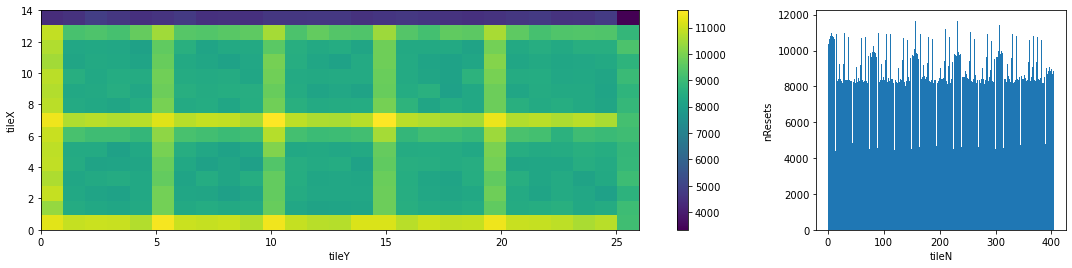

In [11]:
scale = 150
# view of tiles
x = df['tileX'].values
y = df['tileY'].values

fig, ax = plt.subplots(1, 2, figsize =(yMAX/scale*1.5, xMAX/scale), gridspec_kw={'width_ratios': [3, 1]})

h = ax[0].hist2d(y, x, bins=[len(df['tileY'].unique()), len(df['tileX'].unique())])
ax[0].set_ylabel('tileX')
ax[0].set_xlabel("tileY")
fig.colorbar(h[3], ax=ax[0])

tiles = df['tileN'].values
ax[1].hist(tiles, bins=405, range=(0,405))
ax[1].set_xlabel('tileN')
ax[1].set_ylabel('nResets')
plt.tight_layout()
plt.savefig("TileHits_long.pdf")

#### Visualize resets based on ASIC

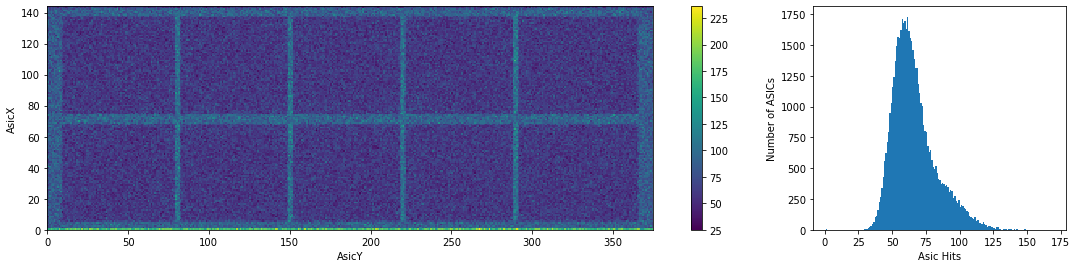

In [12]:
# view of asics
x = df['AsicX'].values
y = df['AsicY'].values

xZoom, yZoom =  1, 1

fig, ax = plt.subplots(1, 2, figsize =(yMAX/scale*1.5, xMAX/scale), gridspec_kw={'width_ratios': [3, 1]})
# h = ax[0].hist2d(y, x, bins=[len(df['AsicY'].unique()), len(df['AsicX'].unique())])
h = ax[0].hist2d(y, x, bins=[int(yMAX/channelYdim/yZoom), int(xMAX/channelXdim/xZoom)], range=[[0, ceil(yMAX/channelYdim/yZoom)], [0, ceil(xMAX/channelXdim/xZoom)]])
ax[0].set_ylabel('AsicX')
ax[0].set_xlabel("AsicY")
fig.colorbar(h[3], ax=ax[0])

countAsics = df['AsicN'].value_counts()
counts = countAsics.unique()
maxCount = max(counts)
ax[1].hist(countAsics, bins=maxCount, range=(0, maxCount))
ax[1].set_ylabel("Number of ASICs")
ax[1].set_xlabel("Asic Hits")
plt.tight_layout()
plt.savefig("AsicHits_long.pdf")

### visualize based on pixel

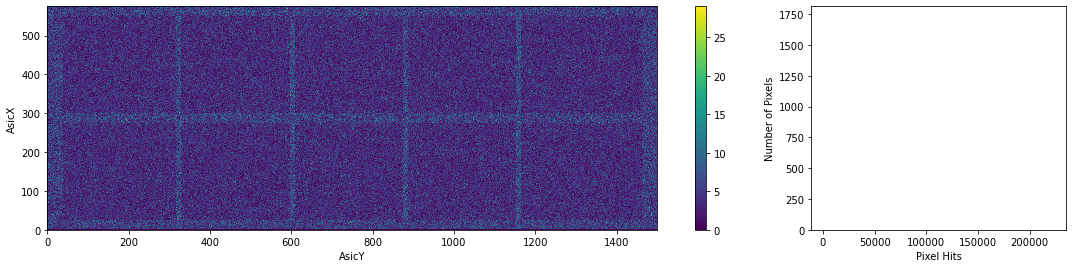

In [13]:
# view of asics
x = df['pX'].values
y = df['pY'].values

xZoom, yZoom =  1, 1

fig, ax = plt.subplots(1, 2, figsize =(yMAX/scale*1.5, xMAX/scale), gridspec_kw={'width_ratios': [3, 1]})
# h = ax[0].hist2d(y, x, bins=[len(df['AsicY'].unique()), len(df['AsicX'].unique())])
h = ax[0].hist2d(y, x, bins=[int(yMAX/yZoom), int(xMAX/xZoom)], range=[[0, ceil(yMAX/yZoom)], [0, ceil(xMAX/xZoom)]])
ax[0].set_ylabel('AsicX')
ax[0].set_xlabel("AsicY")
fig.colorbar(h[3], ax=ax[0])

countPixels = df['nPix'].value_counts()
counts = countPixels.unique()
maxCount = max(counts)
ax[1].hist(countAsics, bins=maxCount, range=(0, maxCount))
ax[1].set_ylabel("Number of Pixels")
ax[1].set_xlabel("Pixel Hits")
plt.tight_layout()
plt.savefig("PixelHits_long.pdf")

25 665688.0    25
667218.0    25
666158.0    25
172488.0    25
845141.0    25
            ..
254047.0     1
612561.0     1
127723.0     1
474890.0     1
438988.0     1
Name: PixN, Length: 834510, dtype: int64


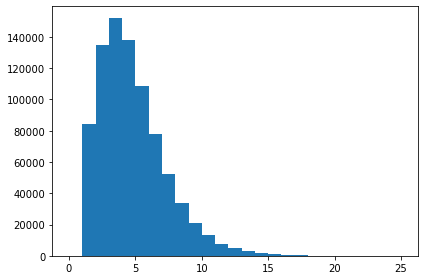

In [32]:
counts = df['PixN'].value_counts()
# counts = countPixels.unique()
maxCount = max(counts)
plt.hist(counts, bins=int(maxCount), range=(0, maxCount))
# plt.set_ylabel("Number of Pixels")
# plt.set_xlabel("Pixel Hits")
plt.tight_layout()
plt.savefig("PixelHits_long.pdf")
print(maxCount, countPixels)

### Identify source for 'bars' in center pattern

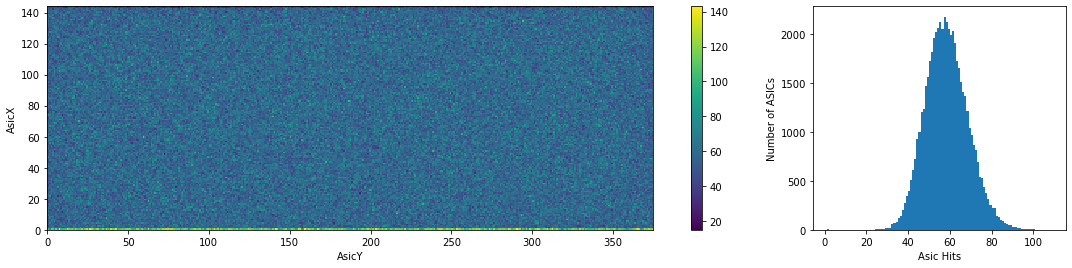

In [14]:
cdf = df[df['Isotope'] != "K40"]

x = cdf['AsicX'].values
y = cdf['AsicY'].values

fig, ax = plt.subplots(1, 2, figsize =(yMAX/scale*1.5, xMAX/scale), gridspec_kw={'width_ratios': [3, 1]})
h = ax[0].hist2d(y, x, bins=[int(yMAX/channelYdim/yZoom), int(xMAX/channelXdim/xZoom)], range=[[0, ceil(yMAX/channelYdim/yZoom)], [0, ceil(xMAX/channelXdim/xZoom)]])
ax[0].set_ylabel('AsicX')
ax[0].set_xlabel("AsicY")
fig.colorbar(h[3], ax=ax[0])

countAsics = cdf['AsicN'].value_counts()
counts = countAsics.unique()
maxCount = max(counts)
ax[1].hist(countAsics, bins=maxCount, range=(0, maxCount))
ax[1].set_ylabel("Number of ASICs")
ax[1].set_xlabel("Asic Hits")
plt.tight_layout()
plt.savefig("AsicHits_long.pdf")

## Visualize the source of these resets from the isotope causing them

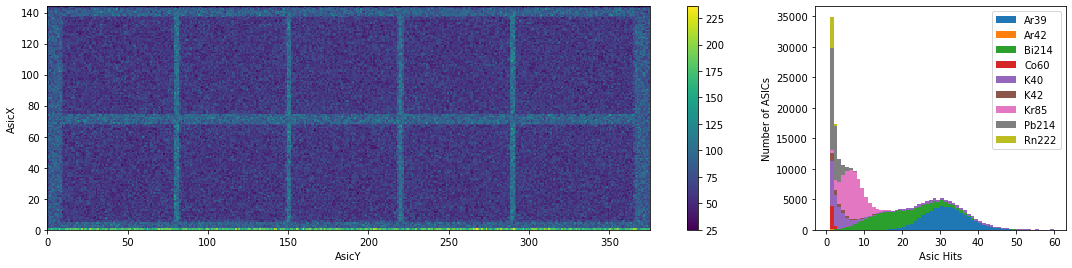

In [15]:
# view of asics
x = df['AsicX'].values
y = df['AsicY'].values

xZoom, yZoom = 1, 1

isotopes = df['Isotope'].unique()

stack_data = []
for iso in isotopes:
    data = df[df['Isotope'] == iso]['AsicN'].value_counts()
    stack_data.append(data)
    
    
fig, ax = plt.subplots(1, 2, figsize =(yMAX/scale*1.5, xMAX/scale), gridspec_kw={'width_ratios': [3, 1]})
h = ax[0].hist2d(y, x, bins=[int(yMAX/channelYdim/yZoom), int(xMAX/channelXdim/xZoom)], range=[[0, ceil(yMAX/channelYdim/yZoom)], [0, ceil(xMAX/channelXdim/xZoom)]])
ax[0].set_ylabel('AsicX')
ax[0].set_xlabel("AsicY")
fig.colorbar(h[3], ax=ax[0])

# ax[1].hist(countAsics, bins=len(counts), log=True, range=(0, maxCount))
ax[1].hist(stack_data, bins=60, range=(0, 60), histtype='bar', stacked=True, log=False, label=isotopes)
ax[1].set_ylabel("Number of ASICs")
ax[1].set_xlabel("Asic Hits")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("AsicHits_isotope_long.pdf")

### Visualize some RTDs based on isotope source as well

In [16]:
# calculate the RTD for *ALL* ASICs within the array to create a maassive heap of RTDs
def makeRTD(reset):
    rtd = []
    for i in range(len(reset)-1):
        rtd.append(reset[i+1] - reset[i])
    return rtd

RTD = []

for i in range(max(df["AsicN"])):
    asic_df = df[df["AsicN"] == i and df["Isotope"] == "Ar39"][["Reset"]].sort_values(by=["Reset"])
    RTD.extend(makeRTD(asic_df["Reset"].values))

plt.hist(RTD)

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [ ]:
plt.hist(RTD, bins=100, log=True, range=(0, 1e-6))

### take the most active column and create a csv for its hits

In [ ]:
xmin = bestX
xmax = bestX + xDIM
ymin = bestY
ymax = bestY + yDIM

xpos = np.logical_and(npX>=xmin, npX<xmax)
ypos = np.logical_and(npY>=ymin, npY<ymax)
sqpos = np.logical_and(xpos, ypos)

bViewHits = True
if bViewHits:
    ax = plt.axes(projection='3d')
    ax.scatter3D(npX[sqpos], npY[sqpos], npResets[sqpos])
    ax.set_xlabel("X-Pixel")
    ax.set_ylabel("Y-Pixel")
    ax.set_zlabel("Reset Time (s)")
    print(f"Found most active tile at (x,y): ({bestX}, {bestY}) with {len(npX[sqpos])} resets.")

#### filter DF and store into CSV: pixel_x, pixel_y, asic_x, asic_y, reset_time

In [ ]:
# Pandas filter since all of the data is here, anyways
fdf = df[ (df["pX"] >= bestX) & (df["pX"] < (bestX + xDIM)) & (df["pY"] >= bestY) & (df["pY"] < (bestY + yDIM)) ]

In [ ]:
# create the tile's dataframe to send into the QPixAsicArray
tiledf = {}
tiledf["nrows"] = arrayXdim
tiledf["ncols"] = arrayYdim
tiledf["hits"] = []

# normalize asic numbers: this is for the simulation input which "0 numbers" the asic's within it's rows / cols
hitX = fdf["AsicX"].unique()
hitY = fdf["AsicY"].unique()
minX = min(hitX)
minY = min(hitY)

# build the hits tuple for each asic within the tile
for x in hitX:
    for y in hitY:
        asicResets = fdf[ (fdf["AsicX"] == x) & (fdf["AsicY"] == y) ][["Reset","nPix"]].values.tolist()
        # print(len(asicResets))
        arrayX = x if minX == 0 else int(x%minX)
        arrayY = y if minY == 0 else int(y%minY)
        tiledf["hits"].append([arrayX, arrayY, asicResets])

# store the values within a json file
import json
outf = "/mnt/c/Users/keefe/OneDrive/Documents/qpix-digital/simulation-software/tiledf_long.json"
with open(outf, "w") as outputFile:
    json.dump(tiledf, outputFile, indent=4)

In [ ]:
# reading in the json file
import codecs
obj_text = codecs.open(outf, 'r').read()
readDF = json.loads(obj_text)
print(readDF["hits"][:2])